In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as xp

In [29]:
namo=pd.read_csv('/content/modi_reviews.csv')
raho=pd.read_csv('/content/rahul_reviews.csv')

In [30]:
namo.head()

,Unnamed: 0,User,Tweet
0,0,advosushildixit,@anjanaomkashyap I am seeing you as future #bj...
1,1,jiaeur,#LokSabhaElections2019 \n23rd May 2019 will re...
2,2,PVenkatGandhi,#LokSabhaElections2019 \n23rd May 2019 will re...
3,3,TheNirbhay1,PM Modi creates a new record of being the only...
4,4,ShakeChilli,@abhijitmajumder Appointment of Successor! \n\...


In [31]:
raho.head()


,Unnamed: 0,User,Tweet
0,0,Sunnysweet16,Wonder why no academic or journalist asks INC ...
1,1,drnitinchaube,Congrats for the change #australiavotes2019 an...
2,2,mrvivek07,Peopel Say “Govt Ne 70 Years Kya kiya”.\nUnse ...
3,3,JosephPravinP,"@ajaymaken @RahulGandhi And as a final touch, ..."
4,4,VandanaMegastar,#LokSabhaElections2019 Anyone not having mass ...


In [32]:
#shape of both
print('raho',raho.shape)
print('namo',namo.shape)

raho (14261, 3)
namo (25688, 3)


In [33]:
#info of both
print('raho',raho.info())
print('namo',namo.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14261 entries, 0 to 14260
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  14261 non-null  int64 
 1   User        14261 non-null  object
 2   Tweet       14261 non-null  object
dtypes: int64(1), object(2)
memory usage: 334.4+ KB
raho None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25688 entries, 0 to 25687
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  25688 non-null  int64 
 1   User        25683 non-null  object
 2   Tweet       25683 non-null  object
dtypes: int64(1), object(2)
memory usage: 602.2+ KB
namo None


In [34]:
namo['Tweet'][1]


'#LokSabhaElections2019 \n23rd May 2019 will reveal ..\nEven ECISVEEP could not help Modi Win 🤔\n\nJanatab Mann Banaata Hai to\nChupke Se Be Jor Se Tappad Deta Hai ..'

In [35]:
from textblob import TextBlob
blob=TextBlob(namo['Tweet'][0])
print(blob.sentiment)

Sentiment(polarity=0.35, subjectivity=0.36250000000000004)


In [36]:
#creating a polarity feature  from the existing dataset
namo.head()

,Unnamed: 0,User,Tweet
0,0,advosushildixit,@anjanaomkashyap I am seeing you as future #bj...
1,1,jiaeur,#LokSabhaElections2019 \n23rd May 2019 will re...
2,2,PVenkatGandhi,#LokSabhaElections2019 \n23rd May 2019 will re...
3,3,TheNirbhay1,PM Modi creates a new record of being the only...
4,4,ShakeChilli,@abhijitmajumder Appointment of Successor! \n\...


In [37]:
namo['Tweet']=namo['Tweet'].astype(str)
raho['Tweet']=raho['Tweet'].astype(str)

def find_polarity(review):
  return TextBlob(review).sentiment.polarity
namo['polarity']=namo['Tweet'].apply(find_polarity)
raho['polarity']=raho['Tweet'].apply(find_polarity)


In [38]:
namo.head(3)


,Unnamed: 0,User,Tweet,polarity
0,0,advosushildixit,@anjanaomkashyap I am seeing you as future #bj...,0.35
1,1,jiaeur,#LokSabhaElections2019 \n23rd May 2019 will re...,0.80
2,2,PVenkatGandhi,#LokSabhaElections2019 \n23rd May 2019 will re...,0.80


In [39]:
#converting all the columns into lower casing
namo.columns=namo.columns.str.lower()
raho.columns=raho.columns.str.lower()

In [40]:
#lower casing all rows
namo['tweet']=namo['tweet'].str.lower().str.strip()
namo['user']=namo['user'].str.lower().str.strip()


raho['tweet']=raho['tweet'].str.lower().str.strip()
raho['user']=raho['user'].str.lower().str.strip()

In [41]:
#html tags cleaning
import re
def clean_html(text):
    if isinstance(text, str):
        return re.sub(r'<.*?>', '', text)
    return ''
namo['tweet'] = namo['tweet'].apply(clean_html)
raho['tweet'] = raho['tweet'].apply(clean_html)
raho['user'] = raho['user'].apply(clean_html)
namo['user'] = namo['user'].apply(clean_html)



In [42]:
namo.head()

,unnamed: 0,user,tweet,polarity
0,0,advosushildixit,@anjanaomkashyap i am seeing you as future #bj...,0.350000
1,1,jiaeur,#loksabhaelections2019 \n23rd may 2019 will re...,0.800000
2,2,pvenkatgandhi,#loksabhaelections2019 \n23rd may 2019 will re...,0.800000
3,3,thenirbhay1,pm modi creates a new record of being the only...,0.312121
4,4,shakechilli,@abhijitmajumder appointment of successor! \n\...,0.098788


In [43]:
#reomving emoji
!pip install emoji
import emoji

def remove_emoji(text):
    if isinstance(text, str):
        return emoji.replace_emoji(text, replace='')
    return text

namo['tweet'] = namo['tweet'].apply(remove_emoji)
raho['tweet'] = raho['tweet'].apply(remove_emoji)
raho['user'] = raho['user'].apply(remove_emoji)
namo['user'] = namo['user'].apply(remove_emoji)


In [44]:
namo.head()

,unnamed: 0,user,tweet,polarity
0,0,advosushildixit,@anjanaomkashyap i am seeing you as future #bj...,0.350000
1,1,jiaeur,#loksabhaelections2019 \n23rd may 2019 will re...,0.800000
2,2,pvenkatgandhi,#loksabhaelections2019 \n23rd may 2019 will re...,0.800000
3,3,thenirbhay1,pm modi creates a new record of being the only...,0.312121
4,4,shakechilli,@abhijitmajumder appointment of successor! \n\...,0.098788


In [45]:
#removing digits
def remove_digits(text):
  if isinstance(text,str):
    text=re.sub(r'\d+','',text)
    return text

namo['tweet'] = namo['tweet'].apply(remove_digits)
raho['tweet'] = raho['tweet'].apply(remove_digits)
raho['user'] = raho['user'].apply(remove_digits)
namo['user'] = namo['user'].apply(remove_digits)


In [46]:
namo.head()

,unnamed: 0,user,tweet,polarity
0,0,advosushildixit,@anjanaomkashyap i am seeing you as future #bj...,0.350000
1,1,jiaeur,#loksabhaelections \nrd may will reveal ..\ne...,0.800000
2,2,pvenkatgandhi,#loksabhaelections \nrd may will reveal ..\ne...,0.800000
3,3,thenirbhay,pm modi creates a new record of being the only...,0.312121
4,4,shakechilli,@abhijitmajumder appointment of successor! \n\...,0.098788


In [47]:
#import re

def remove_punctuation(text):
    if isinstance(text, str):
        return re.sub(r'[^\w\s]', '', text)
    return text
namo['tweet'] = namo['tweet'].apply(remove_punctuation)
raho['tweet'] = raho['tweet'].apply(remove_punctuation)
raho['user'] = raho['user'].apply(remove_punctuation)
namo['user'] = namo['user'].apply(remove_punctuation)

In [48]:
#removing urls

import re

def remove_urls(text):
    if isinstance(text, str):
        return re.sub(r'http\S+|www\S+', '', text)
    return text
namo['tweet'] = namo['tweet'].apply(remove_urls)
raho['tweet'] = raho['tweet'].apply(remove_urls)
raho['user'] = raho['user'].apply(remove_urls)
namo['user'] = namo['user'].apply(remove_urls)

In [49]:
#removing stop words
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words=set(stopwords.words('english'))

def remove_stopwords(text):
  if isinstance(text,str):
    words=text.split()
    return ' '.join([word for word in words if word not in stop_words])
    return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [50]:
namo['tweet'] = namo['tweet'].apply(remove_stopwords)
raho['tweet'] = raho['tweet'].apply(remove_stopwords)
raho['user'] = raho['user'].apply(remove_stopwords)
namo['user'] = namo['user'].apply(remove_stopwords)


In [51]:
namo.head()

,unnamed: 0,user,tweet,polarity
0,0,advosushildixit,anjanaomkashyap seeing future bjp spokesperson...,0.350000
1,1,jiaeur,loksabhaelections rd may reveal even ecisveep ...,0.800000
2,2,pvenkatgandhi,loksabhaelections rd may reveal even ecisveep ...,0.800000
3,3,thenirbhay,pm modi creates new record pm democratic count...,0.312121
4,4,shakechilli,abhijitmajumder appointment successor god forb...,0.098788


In [52]:
raho['tweet'][5]

'incindia release video rahulgandhi visiting kedarnath shrine modi immediately would study contrast amp important everyone comprehend kedarnathtemple kedarnath rahulgandhi'

In [53]:
#leminiziation
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    if isinstance(text, str):
        words = text.split()
        return " ".join([lemmatizer.lemmatize(word) for word in words])
    return text


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [54]:
namo['tweet'] = namo['tweet'].apply(lemmatize_text)
raho['tweet'] = raho['tweet'].apply(lemmatize_text)
raho['user'] = raho['user'].apply(lemmatize_text)
namo['user'] = namo['user'].apply(lemmatize_text)

In [55]:
namo.head()

,unnamed: 0,user,tweet,polarity
0,0,advosushildixit,anjanaomkashyap seeing future bjp spokesperson...,0.350000
1,1,jiaeur,loksabhaelections rd may reveal even ecisveep ...,0.800000
2,2,pvenkatgandhi,loksabhaelections rd may reveal even ecisveep ...,0.800000
3,3,thenirbhay,pm modi creates new record pm democratic count...,0.312121
4,4,shakechilli,abhijitmajumder appointment successor god forb...,0.098788


#creating a label feature basically output column which tells the results and i create this from polarity feature based on the score we get in polarity columns

In [60]:

import numpy as np

namo['label'] = np.where(
    namo['polarity'] > 0, 'positive',
    np.where(namo['polarity'] < 0, 'negative', 'Neutral')
)

raho['label'] = np.where(
    raho['polarity'] > 0, 'positive',
    np.where(raho['polarity'] < 0, 'negative', 'Neutral')
)

In [62]:
namo.head()

,unnamed: 0,user,tweet,polarity,label
0,0,advosushildixit,anjanaomkashyap seeing future bjp spokesperson...,0.350000,positive
1,1,jiaeur,loksabhaelections rd may reveal even ecisveep ...,0.800000,positive
2,2,pvenkatgandhi,loksabhaelections rd may reveal even ecisveep ...,0.800000,positive
3,3,thenirbhay,pm modi creates new record pm democratic count...,0.312121,positive
4,4,shakechilli,abhijitmajumder appointment successor god forb...,0.098788,positive


In [76]:
namo['tweet'].iloc[-1]

'timesofindia arvindkejriwal aap sirji pls decide want look like odd even day choice odd day congress even day without congress loksabhaelections election narendramodi bjpindia'

In [100]:
namo.head()
namo['label'].value_counts()

,count
label,
positive,12439
negative,5043


In [98]:
#there is no need of this neutral thing in election prediction
namo=namo[namo['label']!='Neutral']
raho=raho[raho['label']!='Neutral']

In [104]:
print(namo.shape)
print(raho.shape)

(17482, 5)
(9367, 5)


In [106]:
print(namo['label'].value_counts(normalize=True)*100)
print(raho['label'].value_counts(normalize=True)*100)

label
positive    71.153186
negative    28.846814
Name: proportion, dtype: float64
label
positive    66.136436
negative    33.863564
Name: proportion, dtype: float64


In [107]:
#final sentiment score
namo_score = (namo['label']=='positive').mean() - (namo['label']=='negative').mean()
raho_score = (raho['label']=='positive').mean() - (raho['label']=='negative').mean()

print("Namo Score:", namo_score)
print("Rahul Score:", raho_score)

Namo Score: 0.4230637226861915
Rahul Score: 0.3227287285149995


In [109]:
print("Namo Tweets:", len(namo))
print("Rahul Tweets:", len(raho))

Namo Tweets: 17482
Rahul Tweets: 9367


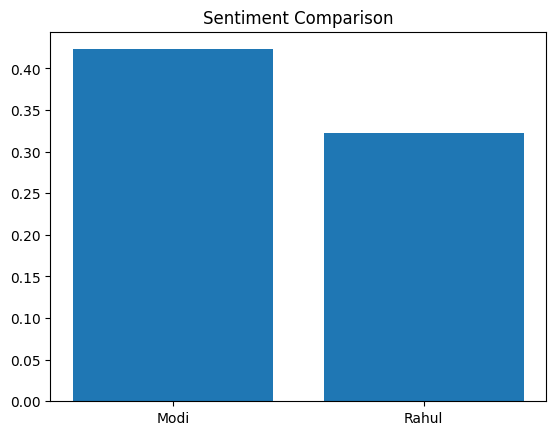

In [110]:
import matplotlib.pyplot as plt

scores = [namo_score, raho_score]
labels = ['Modi', 'Rahul']

plt.bar(labels, scores)
plt.title("Sentiment Comparison")
plt.show()

In [114]:
#combining dataset
namo['candidate'] = 1
raho['candidate'] = 0

df = pd.concat([namo, raho], ignore_index=True)

In [113]:
df.head()

,unnamed: 0,user,tweet,polarity,label,candidate
0,0,advosushildixit,anjanaomkashyap seeing future bjp spokesperson...,0.350000,positive,1
1,1,jiaeur,loksabhaelections rd may reveal even ecisveep ...,0.800000,positive,1
2,2,pvenkatgandhi,loksabhaelections rd may reveal even ecisveep ...,0.800000,positive,1
3,3,thenirbhay,pm modi creates new record pm democratic count...,0.312121,positive,1
4,4,shakechilli,abhijitmajumder appointment successor god forb...,0.098788,positive,1


In [124]:
#features & target
df['tweet'] = df['tweet'].str.lower().str.strip()
X = df['tweet']
y = df['candidate']


In [125]:
#tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['tweet'])

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [127]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8728119180633147


In [128]:
if namo_score > raho_score:
    print("Modi has upper hand based on sentiment analysis")
else:
    print("Rahul has upper hand based on sentiment analysis")

Modi has upper hand based on sentiment analysis
